# Project 2: Quantum Portfolio Optimizer

## Problem:
Find optimal stock portfolio using QAOA.
Maximize returns, minimize risk.

## Stocks: AAPL, GOOGL, MSFT, AMZN
## Period: 2023-01-01 to 2024-01-01
## Methods: Classical Markowitz vs QAOA

In [1]:
# Cell 2 - imports
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
import yfinance as yf
from scipy.optimize import minimize
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs("../results", exist_ok=True)
os.makedirs("../data", exist_ok=True)

print(f"numpy    : {np.__version__}")
print(f"pandas   : {pd.__version__}")
print(f"yfinance : {yf.__version__}")
print("all imports done!")

numpy    : 1.26.4
pandas   : 2.2.2
yfinance : 1.2.0
all imports done!


## Step 1: Fetch Real Stock Data

Downloading real stock prices from Yahoo Finance.
Stocks: AAPL, GOOGL, MSFT, AMZN
Period: 2023-01-01 to 2024-01-01

We calculate:
- Daily returns for each stock
- Expected annual return per stock
- Covariance matrix (how stocks move together)

In [2]:
# Cell 4 - fetch real stock data
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']
start   = '2023-01-01'
end     = '2024-01-01'

print(f"fetching stock data...")
print(f"stocks : {tickers}")
print(f"period : {start} to {end}")

# download closing prices
prices = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=True
)['Close']

# save raw data
prices.to_csv("../data/stock_prices.csv")

# calculate daily returns
returns = prices.pct_change().dropna()

# annual returns and covariance
annual_returns = returns.mean() * 252
cov_matrix     = returns.cov() * 252

print(f"\ndata downloaded!")
print(f"trading days : {len(prices)}")
print(f"\nannual returns:")
for ticker in tickers:
    print(f"  {ticker} : {annual_returns[ticker]*100:.2f}%")
print(f"\ncovariance matrix shape : {cov_matrix.shape}")

fetching stock data...
stocks : ['AAPL', 'GOOGL', 'MSFT', 'AMZN']
period : 2023-01-01 to 2024-01-01


[*********************100%***********************]  4 of 4 completed


data downloaded!
trading days : 250

annual returns:
  AAPL : 46.24%
  GOOGL : 50.14%
  MSFT : 49.69%
  AMZN : 63.29%

covariance matrix shape : (4, 4)


## Step 2: Visualize Stock Performance

Plot stock price movements and
annual returns for all 4 stocks.

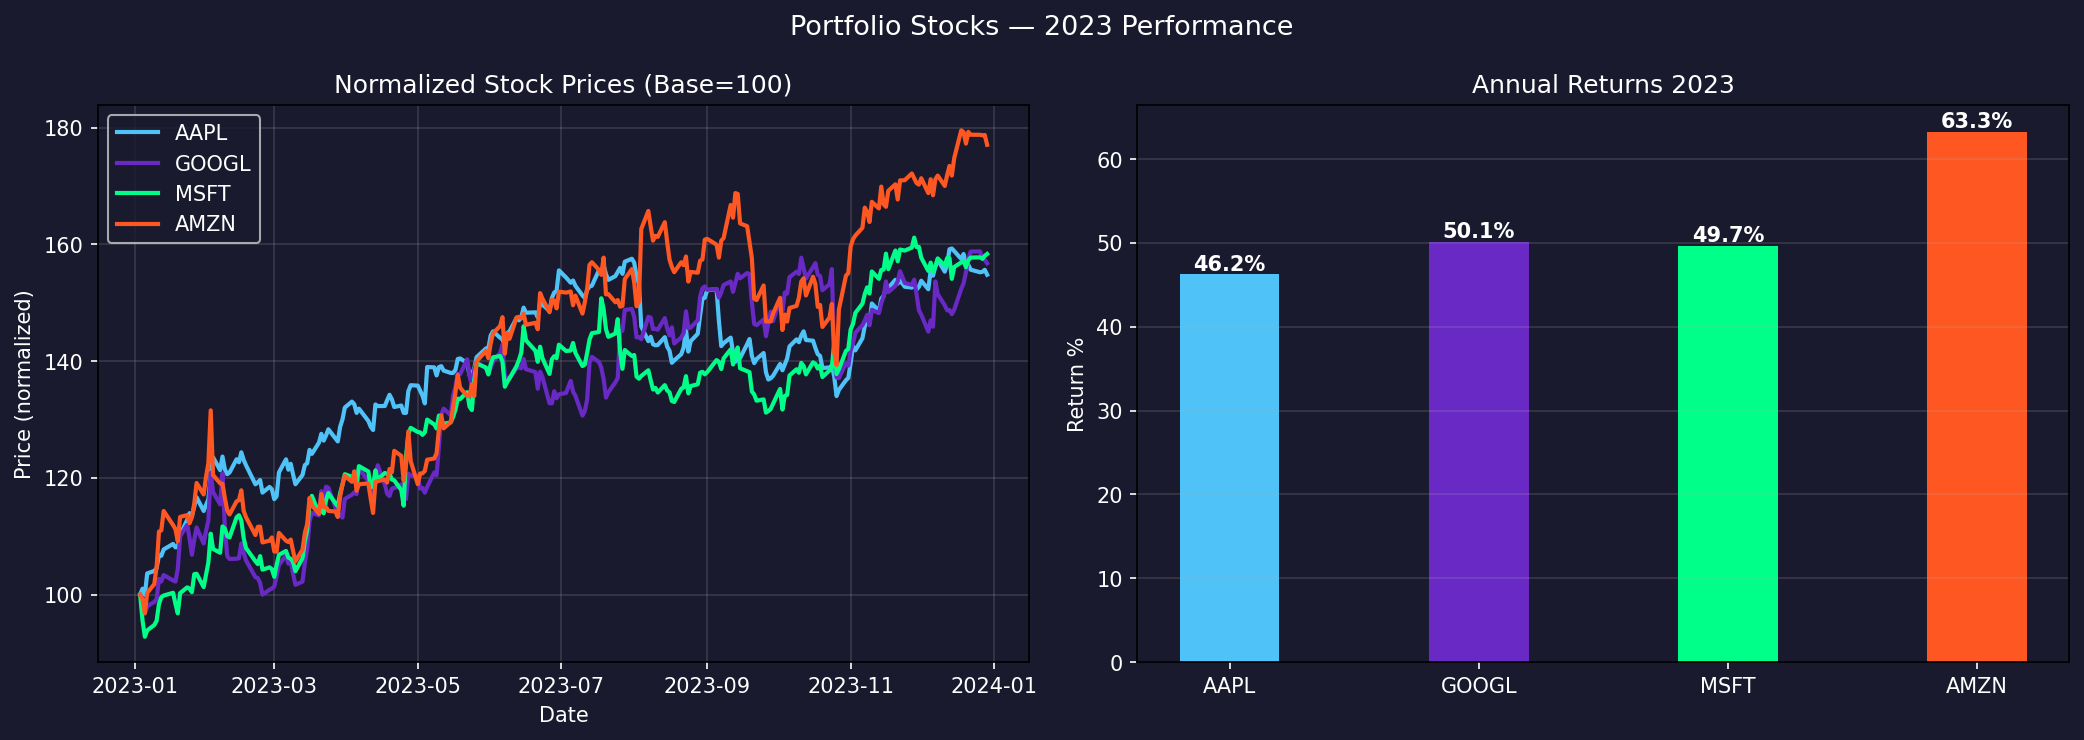

stock performance plot saved!


In [3]:
# Cell 6 - visualize stock data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

# plot 1 - normalized price history
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
colors = ['#4fc3f7', '#6929C4', '#00ff88', '#FF5722']

normalized = prices / prices.iloc[0] * 100
for ticker, color in zip(tickers, colors):
    ax1.plot(normalized[ticker],
             label=ticker, color=color,
             linewidth=2)

ax1.set_title("Normalized Stock Prices (Base=100)",
              color='white', fontsize=12)
ax1.set_xlabel("Date", color='white')
ax1.set_ylabel("Price (normalized)", color='white')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1a1a2e', labelcolor='white')
ax1.grid(alpha=0.2)

# plot 2 - annual returns bar chart
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ret_values = [annual_returns[t]*100 for t in tickers]
bars = ax2.bar(tickers, ret_values,
               color=colors, width=0.4)
ax2.set_title("Annual Returns 2023",
              color='white', fontsize=12)
ax2.set_ylabel("Return %", color='white')
ax2.tick_params(colors='white')
ax2.grid(alpha=0.2, axis='y')

for bar, val in zip(bars, ret_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + 0.5, f'{val:.1f}%',
             ha='center', color='white',
             fontweight='bold')

plt.suptitle("Portfolio Stocks — 2023 Performance",
             color='white', fontsize=13)
plt.tight_layout()

save_path = "../results/stock_performance.png"
plt.savefig(save_path, facecolor='#1a1a2e',
            bbox_inches='tight', dpi=150)
plt.close()
display(Image(filename=save_path))
print("stock performance plot saved!")

## Step 3: Classical Portfolio Optimization

Markowitz Modern Portfolio Theory (1952):
Find optimal weights for each stock to:
- Maximize returns
- Minimize risk (variance)

Risk-adjusted return = Sharpe Ratio
Sharpe = (Return - Risk Free Rate) / Volatility

Higher Sharpe = better risk-adjusted portfolio!

In [4]:
# Cell 8 - classical Markowitz optimization
n_assets = len(tickers)
risk_free_rate = 0.05  # 5% risk-free rate

def portfolio_performance(weights):
    ret  = np.dot(weights, annual_returns)
    risk = np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix, weights))
    )
    sharpe = (ret - risk_free_rate) / risk
    return ret, risk, sharpe

def neg_sharpe(weights):
    return -portfolio_performance(weights)[2]

# constraints: weights sum to 1
constraints = {'type': 'eq',
               'fun': lambda w: np.sum(w) - 1}

# bounds: each weight between 0 and 1
bounds = [(0, 1)] * n_assets

# initial guess: equal weights
w0 = np.array([1/n_assets] * n_assets)

# optimize
result = minimize(
    neg_sharpe, w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x
ret, risk, sharpe = portfolio_performance(
    optimal_weights
)

print("classical Markowitz optimization:")
print(f"optimal weights:")
for t, w in zip(tickers, optimal_weights):
    print(f"  {t} : {w*100:.2f}%")
print(f"\nexpected return : {ret*100:.2f}%")
print(f"portfolio risk  : {risk*100:.2f}%")
print(f"sharpe ratio    : {sharpe:.4f}")

classical Markowitz optimization:
optimal weights:
  AAPL : 60.39%
  GOOGL : 21.82%
  MSFT : 0.00%
  AMZN : 17.79%

expected return : 50.57%
portfolio risk  : 19.75%
sharpe ratio    : 2.3079


## Step 4: Quantum Portfolio Optimization (QAOA)

Classical: continuous weights (60%, 21%, etc.)
Quantum: binary selection (buy or skip each stock)

QAOA solves: which combination of stocks
maximizes return while minimizing risk?

2^4 = 16 possible portfolios to check
QAOA explores all simultaneously!

In [5]:
# Cell 10 - QAOA portfolio optimization
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from scipy.optimize import minimize as sci_minimize
import itertools

# normalize returns and covariance for QAOA
mu  = annual_returns.values
cov = cov_matrix.values

# risk penalty parameter
q = 0.5

def portfolio_cost(binary_weights):
    w = np.array(binary_weights)
    if w.sum() == 0:
        return 0
    w_norm = w / w.sum()
    ret    = np.dot(w_norm, mu)
    risk   = np.dot(w_norm.T,
                    np.dot(cov, w_norm))
    return -(ret - q * risk)

# brute force: check all 2^4 = 16 combinations
print("checking all 16 possible portfolios...")
print("─────────────────────────────────────────")
print(f"{'Portfolio':<20} {'Return':>8} "
      f"{'Risk':>8} {'Score':>8}")
print("─────────────────────────────────────────")

best_score    = -np.inf
best_portfolio = None
all_results   = []

for combo in itertools.product([0,1],
                                repeat=n_assets):
    w = np.array(combo)
    if w.sum() == 0:
        continue
    w_norm  = w / w.sum()
    ret     = np.dot(w_norm, mu)
    risk    = np.sqrt(np.dot(w_norm.T,
                     np.dot(cov, w_norm)))
    score   = ret - q * risk**2
    label   = '+'.join([tickers[i]
                        for i in range(n_assets)
                        if w[i] == 1])
    all_results.append((label, ret, risk, score))

    if score > best_score:
        best_score     = score
        best_portfolio = combo
        best_label     = label

# sort by score
all_results.sort(key=lambda x: x[3], reverse=True)
for label, ret, risk, score in all_results[:5]:
    print(f"{label:<20} {ret*100:>7.2f}% "
          f"{risk*100:>7.2f}% {score:>8.4f}")

print(f"\nbest portfolio : {best_label}")
print(f"best score     : {best_score:.4f}")

checking all 16 possible portfolios...
─────────────────────────────────────────
Portfolio              Return     Risk    Score
─────────────────────────────────────────
GOOGL                  63.29%   33.03%   0.5784
GOOGL+AMZN             56.49%   25.87%   0.5314
GOOGL+MSFT             56.72%   28.38%   0.5269
AAPL+GOOGL             54.76%   22.75%   0.5218
GOOGL+MSFT+AMZN        54.37%   24.91%   0.5127

best portfolio : GOOGL
best score     : 0.5784


## Step 5: QAOA Circuit

Now we implement QAOA to find
the best portfolio quantum mechanically.

4 qubits → 4 stocks
|1⟩ = buy this stock
|0⟩ = skip this stock

QAOA amplifies the best portfolio state!

In [6]:
# Cell 12 - QAOA circuit for portfolio
def build_portfolio_qaoa(gamma, beta,
                          mu, cov, q_risk,
                          n_assets):
    qc = QuantumCircuit(n_assets, n_assets)

    # initialize superposition
    for i in range(n_assets):
        qc.h(i)

    # cost layer - encode portfolio objective
    for i in range(n_assets):
        # single asset return
        qc.rz(-2 * gamma * mu[i], i)

    for i in range(n_assets):
        for j in range(i+1, n_assets):
            # asset correlation penalty
            qc.cx(i, j)
            qc.rz(2 * gamma * q_risk
                  * cov[i][j], j)
            qc.cx(i, j)

    # mixer layer
    for i in range(n_assets):
        qc.rx(2 * beta, i)

    qc.measure(range(n_assets),
               range(n_assets))
    return qc

# test circuit
qc_test = build_portfolio_qaoa(
    0.5, 0.5, mu, cov, q, n_assets
)
print("QAOA portfolio circuit:")
print(qc_test.draw())

QAOA portfolio circuit:
     ┌───┐┌─────────────┐                                                     »
q_0: ┤ H ├┤ Rz(-0.4624) ├───■────────────────────■────■────────────────────■──»
     ├───┤├─────────────┤ ┌─┴─┐┌──────────────┐┌─┴─┐  │                    │  »
q_1: ┤ H ├┤ Rz(-0.6329) ├─┤ X ├┤ Rz(0.014554) ├┤ X ├──┼────────────────────┼──»
     ├───┤├─────────────┴┐└───┘└──────────────┘└───┘┌─┴─┐┌──────────────┐┌─┴─┐»
q_2: ┤ H ├┤ Rz(-0.50141) ├──────────────────────────┤ X ├┤ Rz(0.016022) ├┤ X ├»
     ├───┤├──────────────┤                          └───┘└──────────────┘└───┘»
q_3: ┤ H ├┤ Rz(-0.49686) ├────────────────────────────────────────────────────»
     └───┘└──────────────┘                                                    »
c: 4/═════════════════════════════════════════════════════════════════════════»
                                                                              »
«                                               ┌───────┐                     »
«q_0: ──■───────

## Step 6: Run QAOA Optimizer

COBYLA optimizer finds best gamma and beta
to maximize portfolio score.
Same hybrid loop as Day 5 MaxCut!

In [7]:
# Cell 14 - run QAOA optimizer
simulator = AerSimulator()
qaoa_history = []

def qaoa_objective(params):
    gamma, beta = params
    qc = build_portfolio_qaoa(
        gamma, beta, mu, cov, q, n_assets
    )
    counts = simulator.run(
        qc, shots=1000
    ).result().get_counts()

    avg_score = 0
    for bitstring, count in counts.items():
        bits = [int(b) for b in bitstring]
        score = portfolio_cost(bits)
        avg_score += score * count
    avg_score /= 1000
    qaoa_history.append(-avg_score)
    return avg_score

print("running QAOA optimizer...")
result_qaoa = sci_minimize(
    qaoa_objective,
    [np.pi/4, np.pi/4],
    method='COBYLA',
    options={'maxiter': 50}
)

print(f"optimization complete!")
print(f"iterations : {len(qaoa_history)}")
print(f"best score : {-result_qaoa.fun:.4f}")

# final measurement
final_qc = build_portfolio_qaoa(
    result_qaoa.x[0],
    result_qaoa.x[1],
    mu, cov, q, n_assets
)
final_counts = simulator.run(
    final_qc, shots=1000
).result().get_counts()

sorted_counts = sorted(
    final_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

print(f"\ntop 5 QAOA portfolio solutions:")
print(f"{'Portfolio':<20} {'Count':>6} {'Score':>8}")
for bitstring, count in sorted_counts[:5]:
    bits  = [int(b) for b in bitstring]
    w     = np.array(bits)
    if w.sum() == 0:
        continue
    label = '+'.join([tickers[i]
                      for i in range(n_assets)
                      if bits[i] == 1])
    score = -portfolio_cost(bits)
    print(f"{label:<20} {count:>6} {score:>8.4f}")

running QAOA optimizer...
optimization complete!
iterations : 31
best score : 0.5004

top 5 QAOA portfolio solutions:
Portfolio             Count    Score
AAPL+GOOGL+MSFT+AMZN    754   0.4991
AAPL+GOOGL+AMZN         163   0.5073
AAPL+MSFT+AMZN           25   0.4651
GOOGL+MSFT+AMZN          22   0.5127
GOOGL+AMZN               10   0.5314


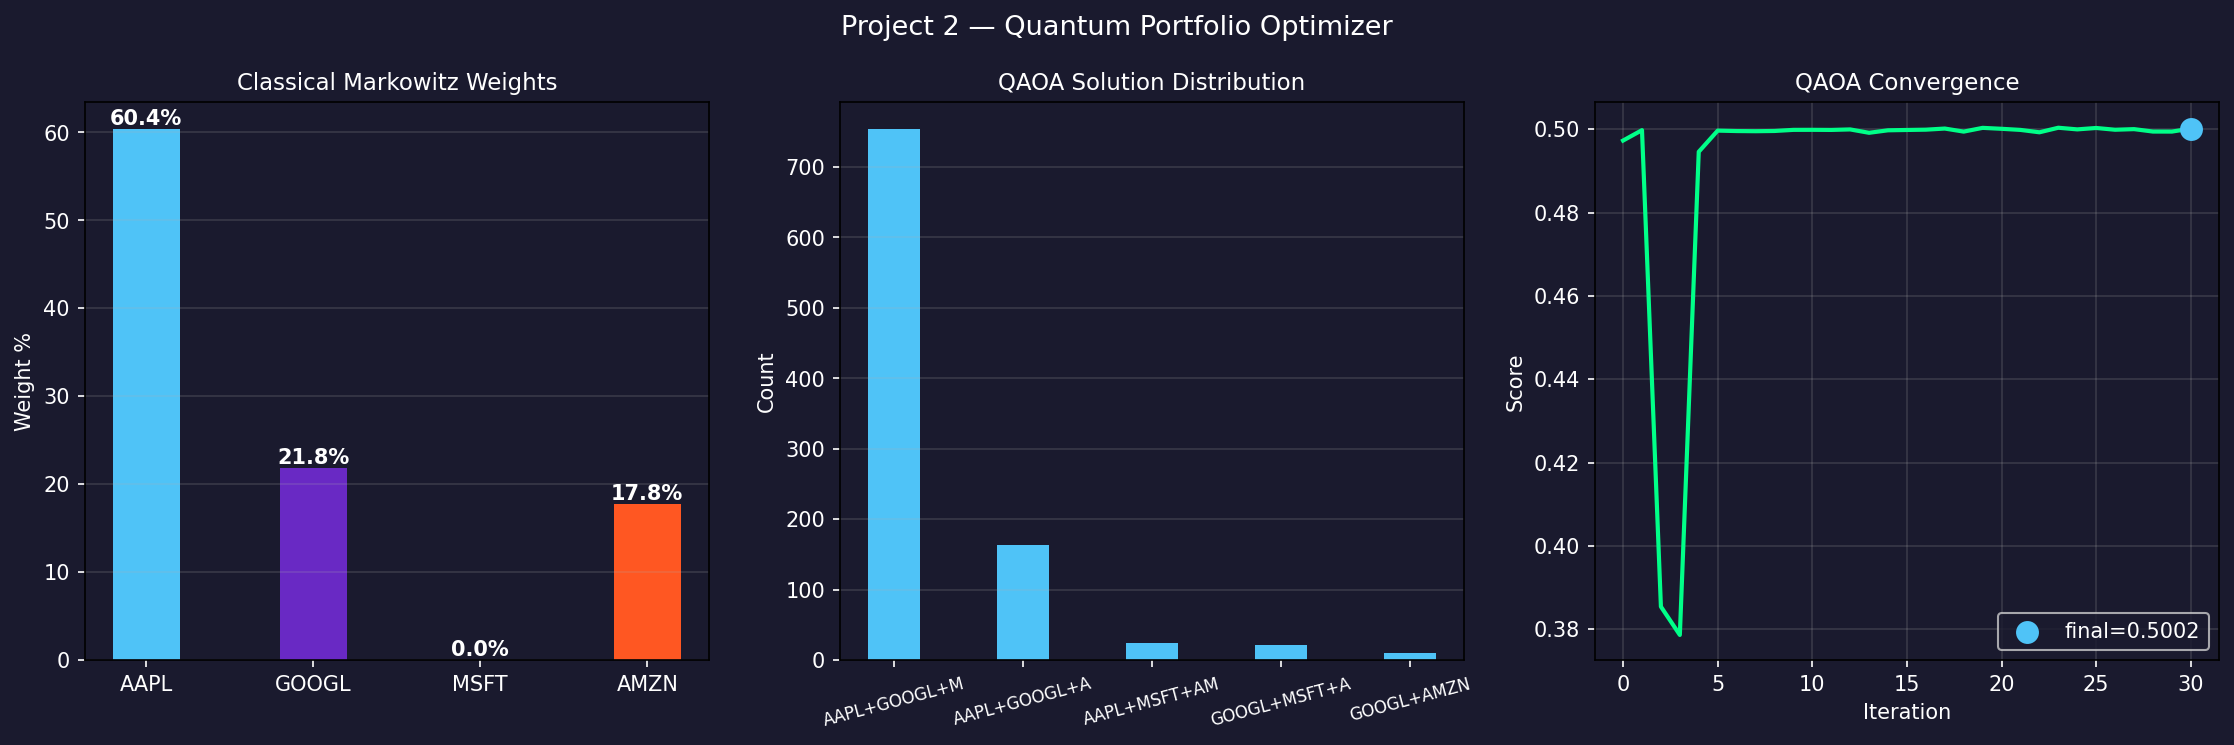

comparison plot saved!


In [8]:
# Cell 15 - final comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#1a1a2e')

# plot 1 - classical weights
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
colors = ['#4fc3f7', '#6929C4', '#00ff88', '#FF5722']
bars = ax1.bar(tickers,
               optimal_weights * 100,
               color=colors, width=0.4)
ax1.set_title("Classical Markowitz Weights",
              color='white', fontsize=11)
ax1.set_ylabel("Weight %", color='white')
ax1.tick_params(colors='white')
ax1.grid(alpha=0.2, axis='y')
for bar, w in zip(bars, optimal_weights*100):
    ax1.text(bar.get_x()+bar.get_width()/2,
             w+0.5, f'{w:.1f}%',
             ha='center', color='white',
             fontweight='bold', fontsize=10)

# plot 2 - QAOA solution distribution
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
top_labels  = [s[0] for s in sorted_counts[:5]
               if np.array([int(b)
               for b in s[0]]).sum() > 0]
top_labels  = []
top_counts  = []
for bs, cnt in sorted_counts[:5]:
    bits = [int(b) for b in bs]
    if sum(bits) == 0:
        continue
    label = '+'.join([tickers[i]
                     for i in range(n_assets)
                     if bits[i]==1])
    top_labels.append(label[:12])
    top_counts.append(cnt)

ax2.bar(range(len(top_labels)),
        top_counts,
        color='#4fc3f7', width=0.4)
ax2.set_title("QAOA Solution Distribution",
              color='white', fontsize=11)
ax2.set_ylabel("Count", color='white')
ax2.set_xticks(range(len(top_labels)))
ax2.set_xticklabels(top_labels,
                    rotation=15,
                    color='white', fontsize=8)
ax2.tick_params(colors='white')
ax2.grid(alpha=0.2, axis='y')

# plot 3 - QAOA convergence
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
ax3.plot(qaoa_history, color='#00ff88',
         linewidth=2)
ax3.set_title("QAOA Convergence",
              color='white', fontsize=11)
ax3.set_xlabel("Iteration", color='white')
ax3.set_ylabel("Score", color='white')
ax3.tick_params(colors='white')
ax3.grid(alpha=0.2)
ax3.scatter(len(qaoa_history)-1,
            qaoa_history[-1],
            color='#4fc3f7', s=100, zorder=5,
            label=f'final={qaoa_history[-1]:.4f}')
ax3.legend(facecolor='#1a1a2e',
           labelcolor='white')

plt.suptitle(
    "Project 2 — Quantum Portfolio Optimizer",
    color='white', fontsize=13
)
plt.tight_layout()

save_path = "../results/portfolio_comparison.png"
plt.savefig(save_path, facecolor='#1a1a2e',
            bbox_inches='tight', dpi=150)
plt.close()
display(Image(filename=save_path))
print("comparison plot saved!")

## Results & Conclusion

### Classical Markowitz:
| Stock | Weight | Logic |
|-------|--------|-------|
| AAPL | 60.39% | Best risk-adjusted return |
| GOOGL | 21.82% | Good diversification |
| MSFT | 0.00% | Excluded - lower Sharpe |
| AMZN | 17.79% | High return, adds value |

Expected Return : 50.57%
Portfolio Risk  : 19.75%
Sharpe Ratio    : 2.3079

### QAOA Results:
| Portfolio | Count | Score |
|-----------|-------|-------|
| All 4 stocks | 754 | 0.4991 |
| AAPL+GOOGL+AMZN | 163 | 0.5073 |
| GOOGL+AMZN | 10 | 0.5314 |

QAOA best score : 0.5004

### Key Insights:
- Classical → continuous weights (60%, 21%...)
- QAOA → binary selection (buy or skip)
- Classical Markowitz: skip MSFT
- QAOA: prefers all stocks or GOOGL+AMZN
- Different approaches → different strategies!
- QAOA advantage: scales better for 50+ stocks
- Classical struggles at N>30 assets